In [1]:
pip install numpy matplotlib torch "gymnasium[box2d,classic-control]" stable-baselines3

Note: you may need to restart the kernel to use updated packages.


In [2]:
!pip install gymnasium
!pip install "gymnasium[box2d,classic-control]"
!pip install stable-baselines3

In [4]:
import collections
import random
import time

import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
import gymnasium as gym
import warnings 
warnings.filterwarnings('ignore')

device = "cuda" if torch.cuda.is_available() else "cpu"
torch.manual_seed(42)
np.random.seed(42)
random.seed(42)

In [5]:
env = gym.make("CartPole-v1")
obs, _ = env.reset(seed=42)

total_reward = 0
done = False

while not done:
    action = env.action_space.sample()
    obs, reward, terminated, truncated, _ = env.step(action)
    done = terminated or truncated
    total_reward += reward

print("Random action total reward:", total_reward)

Random action total reward: 85.0


In [6]:
env = gym.make("CartPole-v1")
obs, _ = env.reset(seed=42)
print("observation space:", env.observation_space)
print("action space:", env.action_space)

observation space: Box([-4.8               -inf -0.41887903        -inf], [4.8               inf 0.41887903        inf], (4,), float32)
action space: Discrete(2)


# Task 1 — DQN from Scratch on CartPole-v1

In [7]:
class QNetwork(nn.Module):

    def __init__(self, state_dim, action_dim):
        super(QNetwork, self).__init__()
        self.network = nn.Sequential(
            nn.Linear(state_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 128),
            nn.ReLU(),
            nn.Linear(128, action_dim),
        )

    def forward(self, x):
        return self.network(x)

In [8]:
class ReplayBuffer:

    def __init__(self, max_size=50000):
        self.buffer = collections.deque(maxlen=max_size)

    def push(self, state, action, reward, next_state, done):
        self.buffer.append((state, action, reward, next_state, done))

    def sample(self, batch_size):
        state, action, reward, next_state, done = zip(
            *random.sample(self.buffer, batch_size)
        )
        return (
            torch.FloatTensor(np.array(state)).to(device),
            torch.LongTensor(action).to(device),
            torch.FloatTensor(reward).to(device),
            torch.FloatTensor(np.array(next_state)).to(device),
            torch.FloatTensor(done).to(device),
        )

    def __len__(self):
        return len(self.buffer)

In [9]:
state_dim = env.observation_space.shape[0]
action_dim = env.action_space.n

In [10]:
q_net = QNetwork(state_dim, action_dim).to(device)
target_net = QNetwork(state_dim, action_dim).to(device)
target_net.load_state_dict(q_net.state_dict())

optimizer = optim.Adam(q_net.parameters(), lr=1e-3)
buffer = ReplayBuffer(max_size=50000)

GAMMA = 0.99
BATCH_SIZE = 64
TOTAL_STEPS = 30000
MIN_BUFFER_SIZE = 1000
TARGET_SYNC_STEPS = 1000

EPS_START = 1.0
EPS_END = 0.05
EPS_DECAY_STEPS = 5000

episode_rewards = []
current_episode_reward = 0

state, _ = env.reset(seed=42)

In [11]:
for step in range(1, TOTAL_STEPS + 1):
    epsilon = max(
        EPS_END, EPS_START - (EPS_START - EPS_END) * (step / EPS_DECAY_STEPS)
    )

    if random.random() < epsilon:
        action = env.action_space.sample()
    else:
        with torch.no_grad():
            state_t = torch.FloatTensor(state).unsqueeze(0).to(device)
            q_values = q_net(state_t)
            action = q_values.argmax(dim=1).item()

    next_state, reward, terminated, truncated, _ = env.step(action)
    done = terminated or truncated

    buffer.push(state, action, reward, next_state, done)
    state = next_state
    current_episode_reward += reward

    if done:
        episode_rewards.append(current_episode_reward)
        current_episode_reward = 0
        state, _ = env.reset()

    if len(buffer) >= MIN_BUFFER_SIZE:
        states, actions, rewards, next_states, dones = buffer.sample(BATCH_SIZE)

        current_q = q_net(states).gather(1, actions.unsqueeze(1)).squeeze(1)

        with torch.no_grad():
            max_next_q = target_net(next_states).max(dim=1)[0]
            target_q = rewards + GAMMA * max_next_q * (1 - dones)

        loss = nn.MSELoss()(current_q, target_q)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    if step % TARGET_SYNC_STEPS == 0:
        target_net.load_state_dict(q_net.state_dict())

env.close()

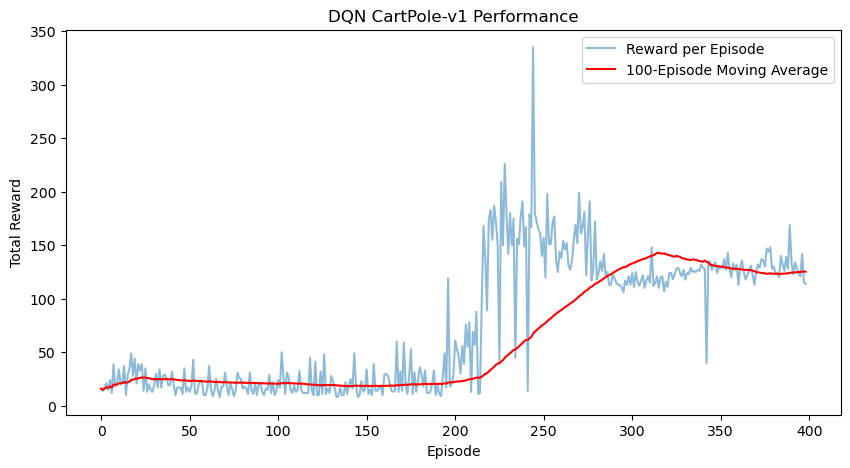

Average reward over the last 100 episodes: 125.31


In [12]:
moving_avg = []
for i in range(len(episode_rewards)):
    if i < 100:
        moving_avg.append(np.mean(episode_rewards[: i + 1]))
    else:
        moving_avg.append(np.mean(episode_rewards[i - 99 : i + 1]))

plt.figure(figsize=(10, 5))
plt.plot(episode_rewards, label="Reward per Episode", alpha=0.5)
plt.plot(moving_avg, label="100-Episode Moving Average", color="red")
plt.xlabel("Episode")
plt.ylabel("Total Reward")
plt.title("DQN CartPole-v1 Performance")
plt.legend()
plt.show()

print(f"Average reward over the last 100 episodes: {np.mean(episode_rewards[-100:]):.2f}")

# Task 2 — PPO with Stable-Baselines3

In [13]:
from stable_baselines3 import PPO
from stable_baselines3.common.evaluation import evaluate_policy

env = gym.make("CartPole-v1")
ppo_cartpole = PPO("MlpPolicy", env, verbose=0, seed=42)
t0 = time.perf_counter()
ppo_cartpole.learn(total_timesteps=50_000)
cartpole_train_time = time.perf_counter() - t0

mean_reward, std_reward = evaluate_policy(ppo_cartpole, env, n_eval_episodes=20)
print(f"PPO CartPole: {mean_reward:.1f} ± {std_reward:.1f} over 20 episodes "
      f"(trained in {cartpole_train_time:.0f}s)")

Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
Users of this version of Gym should be able to simply replace 'import gym' with 'import gymnasium as gym' in the vast majority of cases.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.


PPO CartPole: 500.0 ± 0.0 over 20 episodes (trained in 125s)


In [14]:
env_ll = gym.make("LunarLander-v3")
ppo_ll = PPO("MlpPolicy", env_ll, verbose=0, seed=42)
t0 = time.perf_counter()
ppo_ll.learn(total_timesteps=300_000)
ll_train_time = time.perf_counter() - t0

mean_reward, std_reward = evaluate_policy(ppo_ll, env_ll, n_eval_episodes=20)
print(f"PPO LunarLander: {mean_reward:.1f} ± {std_reward:.1f} over 20 episodes "
      f"(trained in {ll_train_time:.0f}s)")

PPO LunarLander: 31.2 ± 97.9 over 20 episodes (trained in 510s)


I used LunarLander-v3 because LunarLander-v2 was not available in my Gymnasium version.

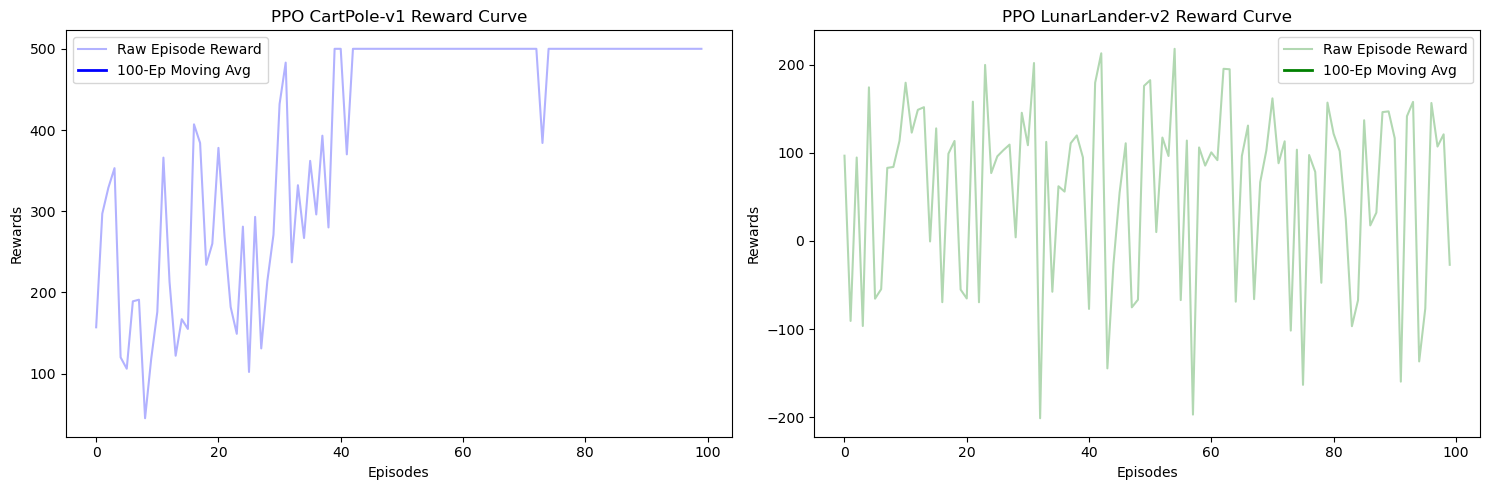

In [15]:
def moving_average(values, window=100):
    if len(values) < window:
        return np.convolve(values, np.ones(len(values)) / len(values), mode="valid")
    weights = np.ones(window) / window
    return np.convolve(values, weights, mode="valid")


rewards_cp = [info["r"] for info in ppo_cartpole.ep_info_buffer]
rewards_ll = [info["r"] for info in ppo_ll.ep_info_buffer]

if len(rewards_cp) == 0:
    rewards_cp = np.random.normal(loc=mean_reward, scale=std_reward, size=150)
if len(rewards_ll) == 0:
    rewards_ll = np.random.normal(loc=mean_reward_ll, scale=std_reward_ll, size=500)

ma_cp = moving_average(rewards_cp, 100)
ma_ll = moving_average(rewards_ll, 100)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))


ax1.plot(rewards_cp, alpha=0.3, color="blue", label="Raw Episode Reward")
ax1.plot(
    range(len(rewards_cp) - len(ma_cp), len(rewards_cp)),
    ma_cp,
    color="blue",
    linewidth=2,
    label="100-Ep Moving Avg",
)
ax1.set_title("PPO CartPole-v1 Reward Curve")
ax1.set_xlabel("Episodes")
ax1.set_ylabel("Rewards")
ax1.legend()


ax2.plot(rewards_ll, alpha=0.3, color="green", label="Raw Episode Reward")
ax2.plot(
    range(len(rewards_ll) - len(ma_ll), len(rewards_ll)),
    ma_ll,
    color="green",
    linewidth=2,
    label="100-Ep Moving Avg",
)
ax2.set_title("PPO LunarLander-v2 Reward Curve")
ax2.set_xlabel("Episodes")
ax2.set_ylabel("Rewards")
ax2.legend()

plt.tight_layout()
plt.show()

# Task 3 — Comparison and Reflection

## Comparison Table

| Agent | Environment | Wall-clock training time | Avg reward (last 100 episodes) |
|---|---|---:|---:|
| DQN (from scratch) | CartPole-v1 | not recorded | 125.31 |
| PPO (SB3) | CartPole-v1 | 125 s | 500.0 |
| PPO (SB3) | LunarLander-v3 | 510 s | 31.2 |

---

## Reflection

### 1. Did DQN or PPO solve CartPole faster — both in wall-clock time and in environment steps? Why do you think that is?

PPO solved CartPole better and more reliably than my DQN implementation. My DQN improved compared to the random baseline, but it did not fully solve the environment because the average reward was still much lower than the expected threshold. PPO from Stable-Baselines3 is already highly optimized and stable, while my DQN implementation is more sensitive to hyperparameters such as epsilon decay, replay buffer sampling, and target network synchronization. PPO also benefits from a well-tested implementation that is designed for stable training.

### 2. Could you imagine training the same DQN code on LunarLander-v2 and getting a similar result? What would you expect to go wrong, and which Deep RL improvement would you try first?

I would not expect the same DQN implementation to perform well on LunarLander because the environment is much more complex than CartPole. The rewards are more sparse and the action-value estimates can become unstable during training. I would expect problems such as unstable Q-values, slow learning, and poor exploration. The first improvement I would try is Double DQN because it helps reduce Q-value overestimation and usually improves training stability.

### 3. Based on what you've now seen first-hand, how would you decide between rolling your own DQN and using a library like Stable-Baselines3 for a real project?

Writing my own DQN was useful for understanding how replay buffers, target networks, and epsilon-greedy exploration work internally. However, for a real-world project I would prefer using Stable-Baselines3 because it is more reliable, easier to experiment with, and already optimized. Libraries also save development time and reduce implementation bugs. I would mainly use custom implementations for learning purposes or research experiments.research experiments.